In [4]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
import os
os.chdir('..')  # go up one level to project root

from src.preprocess import load_and_clean
from src.features import add_features
from src.model import encode_categoricals, compare_models

df = load_and_clean('data/train.csv')
print("Shape:", df.shape)
print("First 5 rows:")
df.head()

Shape: (1460, 81)
First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,12.429220


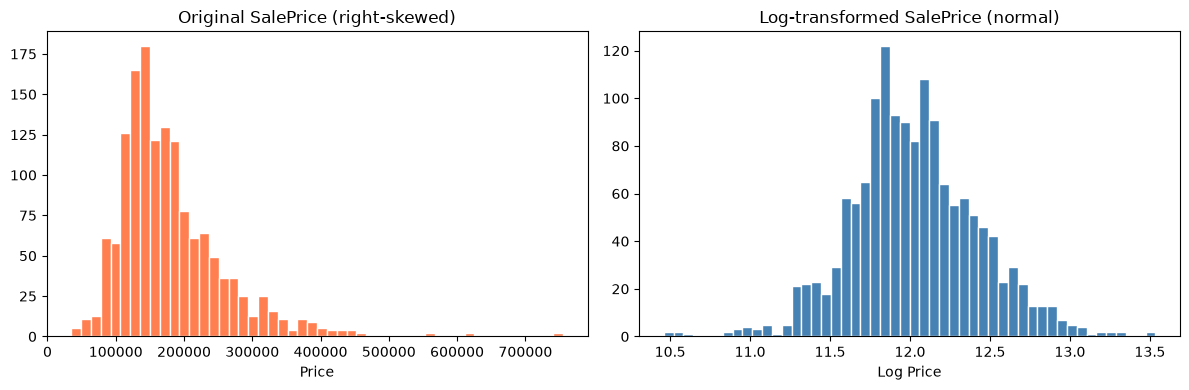

Skewness before log: 1.88
Skewness after log: 0.12


In [5]:
# EDA - Price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

original = pd.read_csv('data/train.csv')['SalePrice']
axes[0].hist(original, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Original SalePrice (right-skewed)')
axes[0].set_xlabel('Price')

axes[1].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log-transformed SalePrice (normal)')
axes[1].set_xlabel('Log Price')

plt.tight_layout()
plt.show()
print("Skewness before log:", round(original.skew(), 2))
print("Skewness after log:", round(df['SalePrice'].skew(), 2))

In [6]:
# Feature Engineering
cols_before = df.shape[1]
df = add_features(df)
cols_after = df.shape[1]

print(f"Columns before: {cols_before}")
print(f"Columns after:  {cols_after}")
print(f"New features added: {cols_after - cols_before}")
print("\nNew columns created:")
print(['TotalSF', 'HouseAge', 'Remodeled', 'TotalBaths', 'LuxuryScore'])

# Show new features
df[['TotalSF', 'HouseAge', 'Remodeled', 'TotalBaths', 'LuxuryScore']].head()

Columns before: 81
Columns after:  86
New features added: 5

New columns created:
['TotalSF', 'HouseAge', 'Remodeled', 'TotalBaths', 'LuxuryScore']


,TotalSF,HouseAge,Remodeled,TotalBaths,LuxuryScore
0,2566,5,0,3.5,35
1,2524,31,0,2.5,48
2,2706,7,1,3.5,35
3,2473,91,1,2.0,35
4,3343,8,0,3.5,40


In [7]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Encode text columns to numbers
X = encode_categoricals(X)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")
print("\nComparing models (this takes 2-3 minutes)...")
best_model = compare_models(X_train, y_train)

Training samples: 1168
Test samples:     292
Features:         85

Comparing models (this takes 2-3 minutes)...
Ridge Regression      RMSE: 0.1594
Random Forest         RMSE: 0.1393
XGBoost               RMSE: 0.1288

Best model: XGBoost


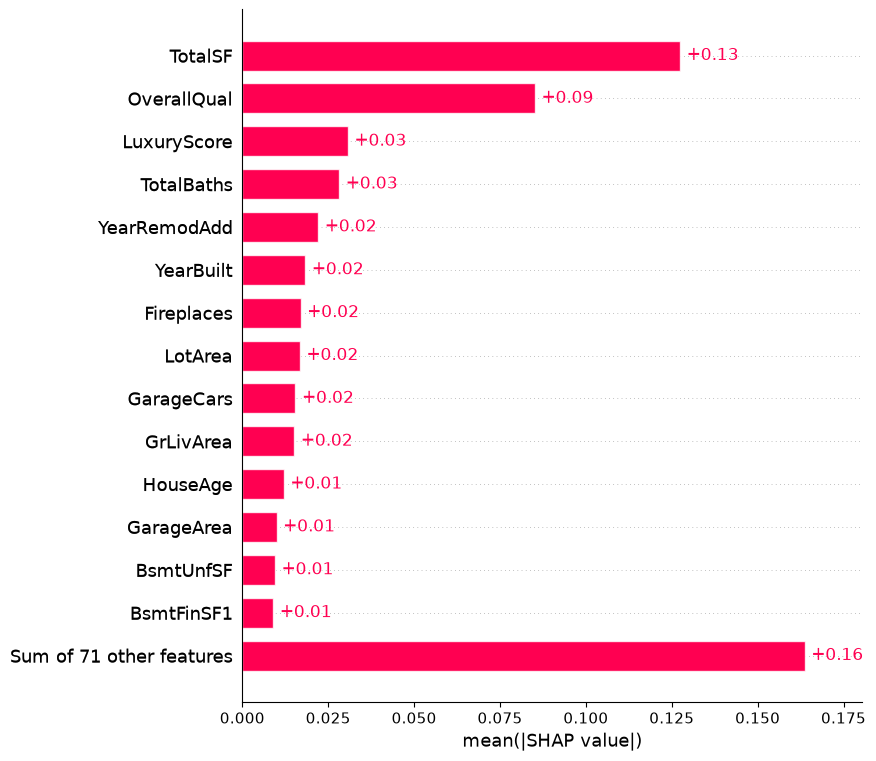

In [8]:
import shap

# Explain why the model made each prediction
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Plot: which features matter most?
shap.plots.bar(shap_values, max_display=15)

## Conclusion

**Best model:** XGBoost with RMSE of 0.1288

**Key findings:**
- XGBoost outperformed Ridge Regression and Random Forest
- Engineered features (TotalSF, LuxuryScore) improved predictions
- Log-transforming SalePrice was critical for model stability

**Author:** Yazhini | B.Tech AIML